# Five-mirror EUV projection-optics simulator (13.5 nm)

This notebook combines two models:

1. **Optiland sequential ray tracing** for a five-mirror, all-reflective projection objective. The starting prescription is the public five-mirror 4:1 reduction design in [US6072852A](https://patents.google.com/patent/US6072852A/en) (Table 5/6 geometry; Table 3 nominal angles of incidence). It is a research starting point, not a prescription for a current commercial scanner.
2. **A NumPy transfer-matrix model** for each vacuum/Ru/(Si/Mo) multilayer/substrate coating. It calculates s, p, and unpolarized reflectivity, including an approximate Nevot-Croce roughness loss.

The outputs are a 13.5 nm ray diagram, reflectivity and cumulative-intensity curves after each mirror, pupil apodization curves, and the final wafer-plane ray footprint. Edit the configuration cell and rerun the notebook to compare layer thickness, individual-layer errors, Ru cap, pair count, roughness, mirror radius, conic, asphere coefficients, aperture, decenter, or tilt.

> **Units:** Optiland uses mm for geometry and micrometres for wavelength. The coating solver uses nm for wavelength, thickness, and roughness. Thus 13.5 nm is passed to Optiland as 0.0135 µm.


In [1]:
# Run once in a fresh environment, then restart the kernel if Jupyter requests it.
%pip install "optiland>=0.5.9,<0.7" numpy matplotlib pandas ipywidgets jinja2


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from copy import deepcopy
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import optiland
from optiland.optic import Optic
from optiland import physical_apertures

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 11})
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
FIGURES_DIR = PROJECT_DIR / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def export_figure(fig, stem, dpi=300):
    """Save a publication PNG and a vector PDF, returning both paths."""
    png_path = FIGURES_DIR / f"{stem}.png"
    pdf_path = FIGURES_DIR / f"{stem}.pdf"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    print(f"Exported {png_path.relative_to(PROJECT_DIR)} and {pdf_path.relative_to(PROJECT_DIR)}")
    return png_path, pdf_path
np.set_printoptions(precision=6, suppress=True)
print("Optiland version:", getattr(optiland, "__version__", "unknown"))
_optiland_probe = Optic()
if not (hasattr(_optiland_probe, "surfaces") or hasattr(_optiland_probe, "surface_group")):
    raise RuntimeError(
        "Optiland was installed or changed in this running kernel. "
        "Restart the Jupyter kernel, then run all cells from the top."
    )
del _optiland_probe
print(f"Data directory: {DATA_DIR}")
print(f"Figure directory: {FIGURES_DIR}")


Optiland version: 0.5.9
Data directory: C:\Users\fxl04\Desktop\Prof. Wong Grp Papers\Mirrors in EUV\data
Figure directory: C:\Users\fxl04\Desktop\Prof. Wong Grp Papers\Mirrors in EUV\figures


## 1. Editable configuration

The patent asphere is

$$z(r)=\frac{c r^2}{1+\sqrt{1-(1+K)c^2r^2}}+A r^4+B r^6+C r^8+D r^{10}.$$

Optiland's `even_asphere` coefficient list begins at $r^2$, so the mapping used below is `[0, A, B, C, D]`. Set `surface_type` to `standard` to retain only the base conic.

For the coating, `layer_overrides_nm` can change any individual layer without changing the other periods. Layers are named from vacuum toward the substrate: `Ru`, `Si_01`, `Mo_01`, ..., `Si_40`, `Mo_40`. For example:

```python
MIRRORS[2]["coating"]["layer_overrides_nm"]["Mo_12"] = 2.90
```


In [3]:
# ---------------- Global controls ----------------
WAVELENGTH_NM = 13.5
WAVELENGTH_UM = WAVELENGTH_NM / 1000.0
OBJECT_DISTANCE_MM = 351.141510
IMAGE_FNO = 2.78
FIELD_Y_MM = [-208.0, -211.0, -214.0]  # three points across the mask ring field
RANDOM_SEED = 7

# Complex n = n_real + i*k in the absorption convention used by this notebook.
# Values are reference values at 13.5 nm; see references at the end.
MATERIALS_13_5NM = {
    "vacuum": 1.0 + 0.0j,
    "Ru": 0.886360034 + 0.017064894j,
    "Si": 0.999002305 + 0.001826494j,
    "Mo": 0.923793525 + 0.006435425j,
    "substrate": 0.973713 + 0.0129764j,
}

BASE_COATING = {
    "n_pairs": 40,
    "d_mo_nm": 2.80,
    "d_si_nm": 4.15,
    "d_ru_nm": 1.50,
    "roughness_nm": 0.25,
    "period_gradient_pct": 0.0,  # linear depth grading: -value to +value
    "layer_overrides_nm": {},
}

# Patent Table 5/6 prescription. thickness_to_next_mm follows Optiland's
# signed sequential-mirror convention. The fourth mirror is the stop.
MIRRORS = [
    dict(name="M1", radius_mm=1 / -0.00078289, thickness_to_next_mm=-292.381122,
         conic=1.62611100, asphere_coeffs=[0.0, 0.0, 3.498200e-16, -7.101160e-22, 0.0],
         surface_type="even_asphere", nominal_aoi_deg=11.34, aoi_half_span_deg=2.0,
         aperture_radius_mm=None, dx_mm=0.0, dy_mm=0.0, rx_rad=0.0, ry_rad=0.0),
    dict(name="M2", radius_mm=1 / -0.00239444, thickness_to_next_mm=504.794891,
         conic=0.33946500, asphere_coeffs=[0.0, 0.0, 5.759030e-15, 9.512560e-20, 0.0],
         surface_type="even_asphere", nominal_aoi_deg=7.72, aoi_half_span_deg=2.0,
         aperture_radius_mm=None, dx_mm=0.0, dy_mm=0.0, rx_rad=0.0, ry_rad=0.0),
    dict(name="M3", radius_mm=1 / -0.00132043, thickness_to_next_mm=-496.445439,
         conic=0.02617400, asphere_coeffs=[0.0, 0.0, 1.143970e-17, 7.746320e-23, 0.0],
         surface_type="even_asphere", nominal_aoi_deg=5.28, aoi_half_span_deg=2.0,
         aperture_radius_mm=None, dx_mm=0.0, dy_mm=0.0, rx_rad=0.0, ry_rad=0.0),
    dict(name="M4", radius_mm=1 / -0.00223166, thickness_to_next_mm=193.582965,
         conic=2.59276100, asphere_coeffs=[0.0, 0.0, -9.009250e-15, -2.722770e-19, 0.0],
         surface_type="even_asphere", nominal_aoi_deg=15.52, aoi_half_span_deg=3.0,
         aperture_radius_mm=None, dx_mm=0.0, dy_mm=0.0, rx_rad=0.0, ry_rad=0.0),
    dict(name="M5", radius_mm=1 / -0.00255085, thickness_to_next_mm=-260.692804,
         conic=0.34659500, asphere_coeffs=[0.0, 0.0, -9.701720e-16, -1.567560e-20, 0.0],
         surface_type="even_asphere", nominal_aoi_deg=7.76, aoi_half_span_deg=2.0,
         aperture_radius_mm=None, dx_mm=0.0, dy_mm=0.0, rx_rad=0.0, ry_rad=0.0),
]
for mirror in MIRRORS:
    mirror["coating"] = deepcopy(BASE_COATING)

# Example edits (uncomment, change, and rerun from this cell):
# MIRRORS[0]["coating"]["d_ru_nm"] = 2.0
# MIRRORS[1]["coating"]["d_mo_nm"] = 2.85
# MIRRORS[2]["coating"]["layer_overrides_nm"]["Si_17"] = 4.05
# MIRRORS[3]["radius_mm"] *= 1.0002
# MIRRORS[4]["conic"] += 0.01

geometry_table = pd.DataFrame([{
    "mirror": m["name"], "radius_mm": m["radius_mm"],
    "to_next_mm": m["thickness_to_next_mm"], "conic": m["conic"],
    "AOI_deg": m["nominal_aoi_deg"], "shape": m["surface_type"]
} for m in MIRRORS])
display(geometry_table.round(6))
geometry_table.to_csv(DATA_DIR / "mirror_geometry.csv", index=False)
pd.DataFrame([{
    "mirror": m["name"], "A_r4_per_mm3": m["asphere_coeffs"][1],
    "B_r6_per_mm5": m["asphere_coeffs"][2],
    "C_r8_per_mm7": m["asphere_coeffs"][3],
    "D_r10_per_mm9": m["asphere_coeffs"][4],
} for m in MIRRORS]).to_csv(DATA_DIR / "asphere_coefficients.csv", index=False)

configuration_export = {
    "wavelength_nm": WAVELENGTH_NM,
    "object_distance_mm": OBJECT_DISTANCE_MM,
    "image_f_number": IMAGE_FNO,
    "field_y_mm": FIELD_Y_MM,
    "mirrors": MIRRORS,
    "optical_constants_13p5nm": {
        name: {"n_real": value.real, "k": value.imag}
        for name, value in MATERIALS_13_5NM.items()
    },
}
(DATA_DIR / "simulation_configuration.json").write_text(
    json.dumps(configuration_export, indent=2), encoding="utf-8"
)
print("Exported mirror geometry, asphere coefficients, and simulation configuration")


,mirror,radius_mm,to_next_mm,conic,AOI_deg,shape
0,M1,-1277.318653,-292.381122,1.626111,11.34,even_asphere
1,M2,-417.634186,504.794891,0.339465,7.72,even_asphere
2,M3,-757.329052,-496.445439,0.026174,5.28,even_asphere
3,M4,-448.096932,193.582965,2.592761,15.52,even_asphere
4,M5,-392.026187,-260.692804,0.346595,7.76,even_asphere


Exported mirror geometry, asphere coefficients, and simulation configuration


## 2. EUV multilayer transfer-matrix model

The solver keeps complex phase through every layer and averages s and p reflected power for an unpolarized beam. The `roughness_nm` term is a compact loss model; it does not explicitly represent silicide interlayers, density gradients, contamination, oxidation, or lateral coating nonuniformity.

The optical constants below are held fixed over the plotted 12.5–14.5 nm interval. That is useful for thickness sensitivity and Bragg-peak movement, but quantitative broadband work should replace `MATERIALS_13_5NM` with measured wavelength-dependent $n(\lambda)+ik(\lambda)$ data.


In [4]:
def build_layer_stack(cfg):
    """Return material names, layer names, and thicknesses from vacuum to substrate."""
    materials, layer_names, thicknesses = [], [], []
    overrides = cfg.get("layer_overrides_nm", {})

    d_ru = overrides.get("Ru", cfg["d_ru_nm"])
    if d_ru > 0:
        materials.append("Ru")
        layer_names.append("Ru")
        thicknesses.append(float(d_ru))

    n_pairs = int(cfg["n_pairs"])
    gradient = float(cfg.get("period_gradient_pct", 0.0)) / 100.0
    for pair in range(1, n_pairs + 1):
        u = 0.0 if n_pairs == 1 else 2.0 * (pair - 1) / (n_pairs - 1) - 1.0
        grade = 1.0 + gradient * u
        for material, key in (("Si", "d_si_nm"), ("Mo", "d_mo_nm")):
            layer_name = f"{material}_{pair:02d}"
            materials.append(material)
            layer_names.append(layer_name)
            thicknesses.append(float(overrides.get(layer_name, cfg[key] * grade)))
    return materials, layer_names, np.asarray(thicknesses, dtype=float)


def _cos_in_layer(n0, n_layer, sin_theta0):
    cos_theta = np.sqrt(1.0 - (n0 * sin_theta0 / n_layer) ** 2 + 0j)
    kz_direction = n_layer * cos_theta
    if np.imag(kz_direction) < -1e-14 or (abs(np.imag(kz_direction)) <= 1e-14 and np.real(kz_direction) < 0):
        cos_theta = -cos_theta
    return cos_theta


def _reflectivity_scalar(cfg, wavelength_nm, aoi_deg, polarization):
    layer_materials, _, d_nm = build_layer_stack(cfg)
    n = np.asarray(
        [MATERIALS_13_5NM["vacuum"]]
        + [MATERIALS_13_5NM[name] for name in layer_materials]
        + [MATERIALS_13_5NM["substrate"]],
        dtype=complex,
    )
    theta0 = np.deg2rad(float(aoi_deg))
    sin_theta0 = np.sin(theta0)
    cos_theta = np.asarray([_cos_in_layer(n[0], nj, sin_theta0) for nj in n])
    k0 = 2.0 * np.pi / float(wavelength_nm)
    kz = k0 * n * cos_theta

    if polarization.lower() == "s":
        q = n * cos_theta
    elif polarization.lower() == "p":
        q = cos_theta / n
    else:
        raise ValueError("polarization must be 's' or 'p'")

    sigma = max(0.0, float(cfg.get("roughness_nm", 0.0)))

    def interface_r(i, j):
        r_ij = (q[i] - q[j]) / (q[i] + q[j])
        # Approximate Nevot-Croce damping. abs() keeps the factor passive
        # for absorbing media while retaining the expected sigma sensitivity.
        damping = np.exp(-2.0 * abs(kz[i] * kz[j]) * sigma**2)
        return r_ij * damping

    n_layers = len(d_nm)
    r_eff = interface_r(n_layers, n_layers + 1)
    for interface in range(n_layers - 1, -1, -1):
        phase = np.exp(2j * kz[interface + 1] * d_nm[interface])
        r_here = interface_r(interface, interface + 1)
        r_eff = (r_here + r_eff * phase) / (1.0 + r_here * r_eff * phase)
    return float(np.clip(abs(r_eff) ** 2, 0.0, 1.0))


def multilayer_reflectivity(cfg, wavelength_nm, aoi_deg, polarization="unpolarized"):
    """Power reflectivity for scalar or array wavelength/AOI inputs."""
    wl, angle = np.broadcast_arrays(
        np.asarray(wavelength_nm, dtype=float), np.asarray(aoi_deg, dtype=float)
    )
    out = np.empty(wl.size, dtype=float)
    for idx, (w, a) in enumerate(zip(wl.ravel(), angle.ravel())):
        if polarization.lower() in ("s", "p"):
            out[idx] = _reflectivity_scalar(cfg, w, a, polarization.lower())
        else:
            rs = _reflectivity_scalar(cfg, w, a, "s")
            rp = _reflectivity_scalar(cfg, w, a, "p")
            out[idx] = 0.5 * (rs + rp)
    out = out.reshape(wl.shape)
    return float(out) if out.ndim == 0 else out


def coating_summary(mirrors=MIRRORS, wavelength_nm=WAVELENGTH_NM):
    cumulative = 1.0
    rows = []
    for m in mirrors:
        cfg = m["coating"]
        r = multilayer_reflectivity(cfg, wavelength_nm, m["nominal_aoi_deg"])
        cumulative *= r
        rows.append({
            "mirror": m["name"], "AOI_deg": m["nominal_aoi_deg"],
            "pairs": cfg["n_pairs"], "Mo_nm": cfg["d_mo_nm"],
            "Si_nm": cfg["d_si_nm"], "Ru_nm": cfg["d_ru_nm"],
            "R_percent": 100 * r, "cumulative_I_percent": 100 * cumulative,
        })
    return pd.DataFrame(rows)

intensity_table = coating_summary()
display(intensity_table.round({
    "AOI_deg": 2, "Mo_nm": 3, "Si_nm": 3, "Ru_nm": 3,
    "R_percent": 2, "cumulative_I_percent": 2,
}))
intensity_table.to_csv(DATA_DIR / "coating_summary_13p5nm.csv", index=False)

optical_constants_table = pd.DataFrame([
    {"material": name, "wavelength_nm": WAVELENGTH_NM,
     "n_real": value.real, "k": value.imag}
    for name, value in MATERIALS_13_5NM.items()
])
optical_constants_table.to_csv(DATA_DIR / "optical_constants_13p5nm.csv", index=False)
for mirror in MIRRORS:
    materials, layer_names, thicknesses = build_layer_stack(mirror["coating"])
    pd.DataFrame({
        "layer_from_vacuum": np.arange(1, len(layer_names) + 1),
        "layer_name": layer_names, "material": materials,
        "thickness_nm": thicknesses,
    }).to_csv(DATA_DIR / f"layer_stack_{mirror['name']}.csv", index=False)
print("Exported coating summary, optical constants, and five layer-stack CSV files")


,mirror,AOI_deg,pairs,Mo_nm,Si_nm,Ru_nm,R_percent,cumulative_I_percent
0,M1,11.34,40,2.8,4.15,1.5,53.10,53.10
1,M2,7.72,40,2.8,4.15,1.5,71.84,38.15
2,M3,5.28,40,2.8,4.15,1.5,73.03,27.86
3,M4,15.52,40,2.8,4.15,1.5,12.50,3.48
4,M5,7.76,40,2.8,4.15,1.5,71.79,2.50


Exported coating summary, optical constants, and five layer-stack CSV files


Exported figures\01_mirror_reflectivity_and_cumulative_intensity.png and figures\01_mirror_reflectivity_and_cumulative_intensity.pdf


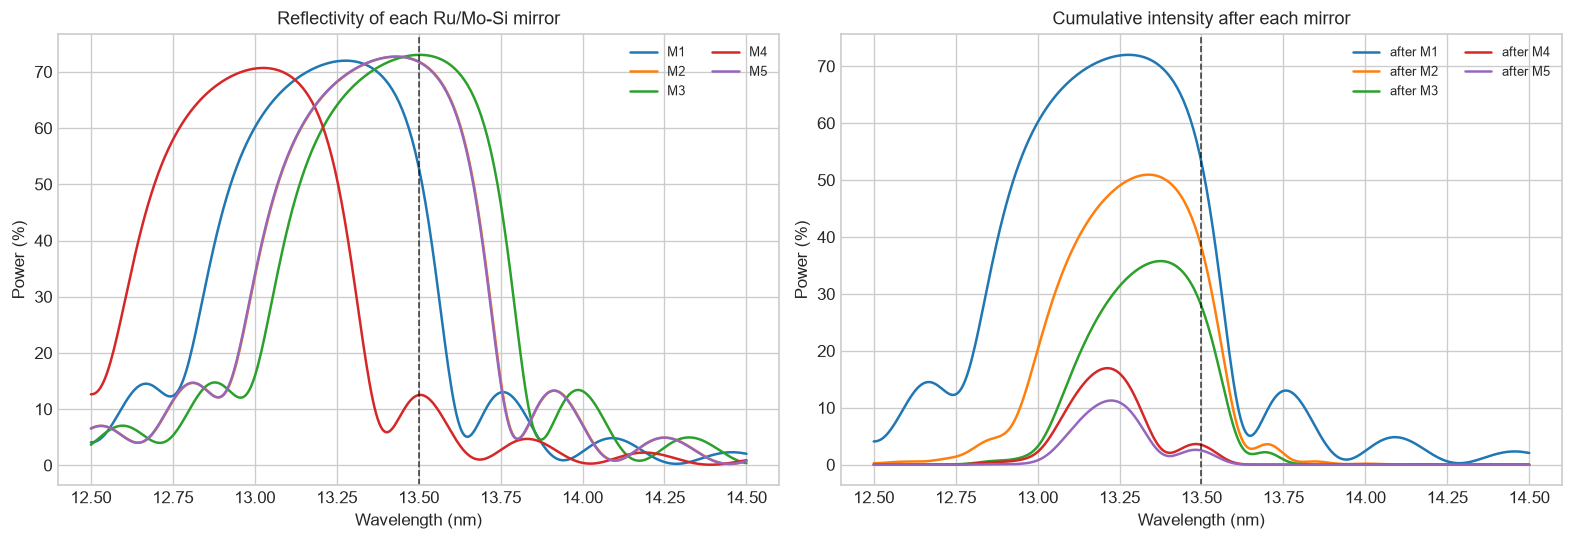

In [5]:
# Individual reflectivity and cumulative intensity after every mirror.
wavelengths_nm = np.linspace(12.5, 14.5, 401)
individual_R = np.vstack([
    multilayer_reflectivity(m["coating"], wavelengths_nm, m["nominal_aoi_deg"])
    for m in MIRRORS
])
cumulative_I = np.cumprod(individual_R, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), constrained_layout=True)
for i, m in enumerate(MIRRORS):
    axes[0].plot(wavelengths_nm, 100 * individual_R[i], label=m["name"])
    axes[1].plot(wavelengths_nm, 100 * cumulative_I[i], label=f"after {m['name']}")
for ax in axes:
    ax.axvline(WAVELENGTH_NM, color="k", ls="--", lw=1, alpha=0.7)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Power (%)")
    ax.legend(ncol=2, fontsize=8)
axes[0].set_title("Reflectivity of each Ru/Mo-Si mirror")
axes[1].set_title("Cumulative intensity after each mirror")

spectrum_data = {"wavelength_nm": wavelengths_nm}
for i, m in enumerate(MIRRORS):
    spectrum_data[f"{m['name']}_reflectivity_fraction"] = individual_R[i]
    spectrum_data[f"after_{m['name']}_cumulative_fraction"] = cumulative_I[i]
pd.DataFrame(spectrum_data).to_csv(DATA_DIR / "reflectivity_spectrum.csv", index=False)
export_figure(fig, "01_mirror_reflectivity_and_cumulative_intensity")
plt.show()


Exported figures\02_pupil_apodization.png and figures\02_pupil_apodization.pdf


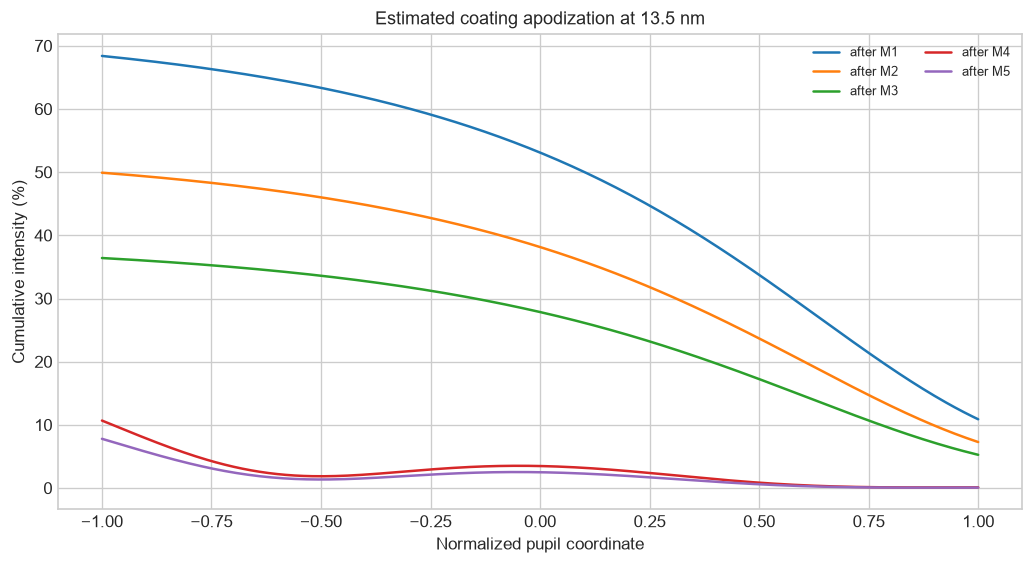

In [6]:
# Approximate pupil apodization caused by AOI variation over each footprint.
# The half-spans are editable engineering estimates in MIRRORS, not ray-derived
# values from the patent. Replace them with measured/optimized footprint AOIs.
pupil = np.linspace(-1.0, 1.0, 301)
running_I = np.ones_like(pupil)
pupil_data = {"normalized_pupil": pupil}

fig, ax = plt.subplots(figsize=(8.5, 4.6), constrained_layout=True)
for m in MIRRORS:
    local_aoi = m["nominal_aoi_deg"] + m["aoi_half_span_deg"] * pupil
    local_R = multilayer_reflectivity(m["coating"], WAVELENGTH_NM, local_aoi)
    running_I *= local_R
    pupil_data[f"{m['name']}_local_AOI_deg"] = local_aoi
    pupil_data[f"{m['name']}_reflectivity_fraction"] = local_R
    pupil_data[f"after_{m['name']}_cumulative_fraction"] = running_I.copy()
    ax.plot(pupil, 100 * running_I, label=f"after {m['name']}")
ax.set(xlabel="Normalized pupil coordinate", ylabel="Cumulative intensity (%)",
       title=f"Estimated coating apodization at {WAVELENGTH_NM:.1f} nm")
ax.legend(ncol=2, fontsize=8)
pd.DataFrame(pupil_data).to_csv(DATA_DIR / "pupil_apodization.csv", index=False)
export_figure(fig, "02_pupil_apodization")
plt.show()


## 3. Build the five-mirror Optiland model

Optiland treats the reflective geometry as ideal mirrors; the multilayer solver above supplies the coating throughput. This prevents a visible-light material catalogue from being extrapolated into the EUV. The signed spacings below are intentional: every reflection reverses the sequential propagation direction.


In [7]:
def build_optiland_system(mirrors=MIRRORS):
    system = Optic(name="Five-mirror EUV projection objective")
    system.add_surface(
        index=0, radius=np.inf, thickness=OBJECT_DISTANCE_MM, comment="Reflective mask / object"
    )

    for surface_index, m in enumerate(mirrors, start=1):
        kwargs = dict(
            index=surface_index,
            radius=m["radius_mm"],
            conic=m["conic"],
            thickness=m["thickness_to_next_mm"],
            material="mirror",
            is_stop=(m["name"] == "M4"),
            comment=m["name"],
            dx=m.get("dx_mm", 0.0), dy=m.get("dy_mm", 0.0),
            rx=m.get("rx_rad", 0.0), ry=m.get("ry_rad", 0.0),
        )
        if m.get("surface_type", "even_asphere") == "even_asphere":
            kwargs.update(surface_type="even_asphere", coefficients=m["asphere_coeffs"])
        else:
            kwargs.update(surface_type=m["surface_type"])
        if m.get("aperture_radius_mm") is not None:
            kwargs["aperture"] = physical_apertures.RadialAperture(
                r_min=0.0, r_max=float(m["aperture_radius_mm"])
            )
        system.add_surface(**kwargs)

    system.add_surface(index=6, radius=np.inf, comment="Wafer / image plane")
    system.set_aperture(aperture_type="imageFNO", value=IMAGE_FNO)
    system.set_field_type(field_type="object_height")
    for field_y in FIELD_Y_MM:
        system.add_field(y=field_y)
    system.add_wavelength(value=WAVELENGTH_UM, is_primary=True)

    # API-compatible update for Optiland 0.5.x variants.
    try:
        system.update_paraxial()
    except AttributeError:
        system.updater.update_paraxial()
    return system

system = build_optiland_system()
system.info()


╒════╤═════════════════════╤══════════════════════════╤═══════════╤═════════════╤════════════╤══════════╤═════════════════╕
│    │ Type                │ Comment                  │    Radius │   Thickness │ Material   │    Conic │ Semi-aperture   │
╞════╪═════════════════════╪══════════════════════════╪═══════════╪═════════════╪════════════╪══════════╪═════════════════╡
│  0 │ Planar              │ Reflective mask / object │   inf     │     351.142 │ Air        │ 0        │ [208.]          │
│  1 │ Even Asphere        │ M1                       │ -1277.32  │    -292.381 │ Mirror     │ 1.62611  │ [205.23329]     │
│  2 │ Even Asphere        │ M2                       │  -417.634 │     504.795 │ Mirror     │ 0.339465 │ [108.972837]    │
│  3 │ Even Asphere        │ M3                       │  -757.329 │    -496.445 │ Mirror     │ 0.026174 │ [206.210706]    │
│  4 │ Stop - Even Asphere │ M4                       │  -448.097 │     193.583 │ Mirror     │ 2.59276  │ [38.117133]     │
│  5 │ E

Exported figures\03_optiland_ray_diagram.png and figures\03_optiland_ray_diagram.pdf


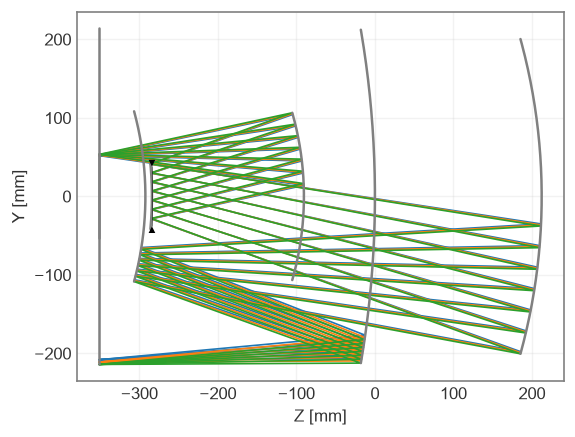

In [8]:
# 13.5 nm meridional ray diagram for the three configured mask-field points.
# If aggressive edits vignette all rays, restore the default spacings/signs first.
draw_result = system.draw(num_rays=7, distribution="line_y")
ray_figure = draw_result[0] if isinstance(draw_result, tuple) else plt.gcf()
export_figure(ray_figure, "03_optiland_ray_diagram")

# Export surface intercepts used to reconstruct/check the meridional path.
ray_diagram_frames = []
try:
    for field_hy in (-1.0, 0.0, 1.0):
        system.trace(Hx=0.0, Hy=field_hy, wavelength=WAVELENGTH_UM,
                     num_rays=7, distribution="line_y")
        traced_surfaces = system.surfaces if hasattr(system, "surfaces") else system.surface_group
        x_hits = np.atleast_2d(np.asarray(traced_surfaces.x, dtype=float))
        y_hits = np.atleast_2d(np.asarray(traced_surfaces.y, dtype=float))
        z_hits = np.atleast_2d(np.asarray(traced_surfaces.z, dtype=float))
        n_surfaces, n_sampled_rays = y_hits.shape
        ray_diagram_frames.append(pd.DataFrame({
            "normalized_field_Hy": field_hy,
            "surface_index": np.repeat(np.arange(n_surfaces), n_sampled_rays),
            "ray_index": np.tile(np.arange(n_sampled_rays), n_surfaces),
            "x_global_mm": x_hits.ravel(),
            "y_global_mm": y_hits.ravel(),
            "z_global_mm": z_hits.ravel(),
        }))
    pd.concat(ray_diagram_frames, ignore_index=True).to_csv(
        DATA_DIR / "ray_diagram_intercepts.csv", index=False
    )
except Exception as exc:
    warnings.warn(f"Ray diagram was saved, but intercept CSV export failed: {exc}")
plt.show()


## 4. Final ray shape at the wafer

The left and middle panels show the centered geometrical spot for the middle ring-field point; the right panel shows all three fields in physical image-plane coordinates. The coating throughput weights the plot but does not change geometrical ray positions. Diffraction, mask pattern propagation, partial coherence, flare, and resist response are outside this geometrical spot calculation.


Exported figures\04_final_wafer_ray_shape.png and figures\04_final_wafer_ray_shape.pdf


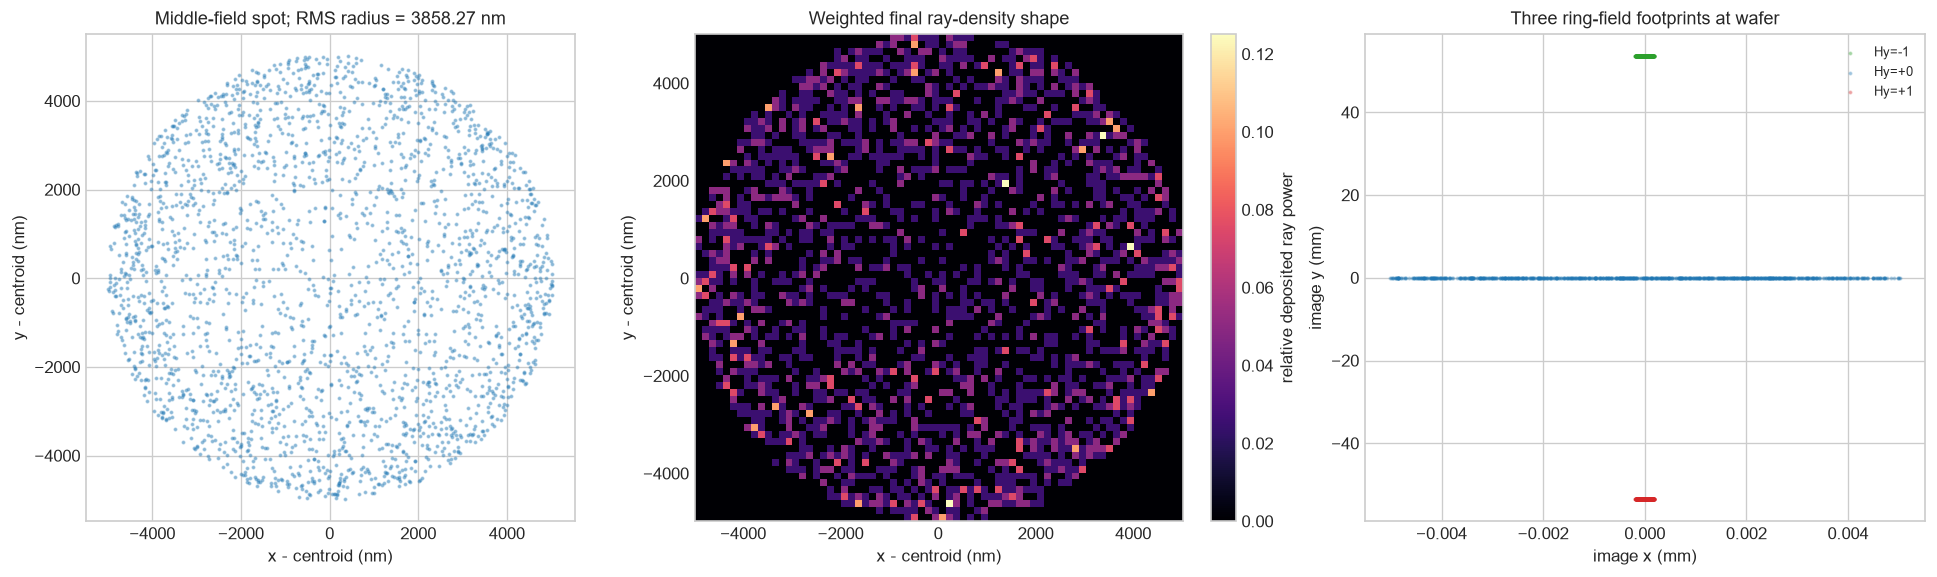

Valid middle-field rays: 2,500
Nominal five-mirror coating throughput: 2.501%
Geometrical RMS spot radius (middle field): 3858.274 nm


In [9]:
def total_coating_throughput(mirrors=MIRRORS, wavelength_nm=WAVELENGTH_NM):
    return float(np.prod([
        multilayer_reflectivity(m["coating"], wavelength_nm, m["nominal_aoi_deg"])
        for m in mirrors
    ]))


def trace_field_spot(optical_system, Hx=0.0, Hy=0.0, num_rays=2000):
    np.random.seed(RANDOM_SEED)
    rays = optical_system.trace(
        Hx=Hx, Hy=Hy, wavelength=WAVELENGTH_UM,
        num_rays=num_rays, distribution="random"
    )
    x = np.asarray(rays.x, dtype=float).ravel()
    y = np.asarray(rays.y, dtype=float).ravel()
    ray_i = np.asarray(getattr(rays, "intensity", np.ones_like(x)), dtype=float).ravel()
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(ray_i) & (ray_i > 0)
    if not np.any(valid):
        raise RuntimeError("No valid rays reached the wafer. Undo the last large geometry/aperture edit.")
    x, y, ray_i = x[valid], y[valid], ray_i[valid]
    weights = ray_i * total_coating_throughput()
    return x, y, weights


x0, y0, w0 = trace_field_spot(system, Hy=0.0, num_rays=2500)
pd.DataFrame({
    "x_image_mm": x0, "y_image_mm": y0, "relative_ray_power": w0
}).to_csv(DATA_DIR / "middle_field_spot.csv", index=False)
xc = np.average(x0, weights=w0)
yc = np.average(y0, weights=w0)
x_nm = (x0 - xc) * 1e6  # 1 mm = 1e6 nm
y_nm = (y0 - yc) * 1e6
rms_nm = np.sqrt(np.average(x_nm**2 + y_nm**2, weights=w0))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.7), constrained_layout=True)
axes[0].scatter(x_nm, y_nm, s=2, alpha=0.35, color="tab:blue")
axes[0].set(title=f"Middle-field spot; RMS radius = {rms_nm:.2f} nm",
            xlabel="x - centroid (nm)", ylabel="y - centroid (nm)")
axes[0].set_aspect("equal", adjustable="box")

h = axes[1].hist2d(x_nm, y_nm, bins=70, weights=w0, cmap="magma")
axes[1].set(title="Weighted final ray-density shape",
            xlabel="x - centroid (nm)", ylabel="y - centroid (nm)")
axes[1].set_aspect("equal", adjustable="box")
fig.colorbar(h[3], ax=axes[1], label="relative deposited ray power")

field_footprint_frames = []
for Hy, color in zip((-1.0, 0.0, 1.0), ("tab:green", "tab:blue", "tab:red")):
    xf, yf, wf = trace_field_spot(system, Hy=Hy, num_rays=900)
    field_footprint_frames.append(pd.DataFrame({
        "normalized_field_Hy": Hy, "x_image_mm": xf,
        "y_image_mm": yf, "relative_ray_power": wf,
    }))
    axes[2].scatter(xf, yf, s=2, alpha=0.28, color=color, label=f"Hy={Hy:+.0f}")
axes[2].set(title="Three ring-field footprints at wafer",
            xlabel="image x (mm)", ylabel="image y (mm)")
axes[2].legend(fontsize=8)
pd.concat(field_footprint_frames, ignore_index=True).to_csv(
    DATA_DIR / "three_field_footprints.csv", index=False
)
pd.DataFrame([{
    "wavelength_nm": WAVELENGTH_NM, "valid_middle_field_rays": len(x0),
    "five_mirror_throughput_fraction": total_coating_throughput(),
    "middle_field_rms_spot_radius_nm": rms_nm,
}]).to_csv(DATA_DIR / "wafer_spot_metrics.csv", index=False)
export_figure(fig, "04_final_wafer_ray_shape")
plt.show()

print(f"Valid middle-field rays: {len(x0):,}")
print(f"Nominal five-mirror coating throughput: {100 * total_coating_throughput():.3f}%")
print(f"Geometrical RMS spot radius (middle field): {rms_nm:.3f} nm")


## 5. Compare a curvature, conic, or asphere change

This helper rebuilds the Optiland model and compares the changed footprint against the current `MIRRORS` baseline. A scale of `1.0002` means a +0.02% radius change. Trial points are plotted relative to the **nominal** centroid so that image displacement is not hidden. Use small changes first; a large change can send all rays outside the sequential path.


Exported figures\05_geometry_sensitivity_m3.png and figures\05_geometry_sensitivity_m3.pdf


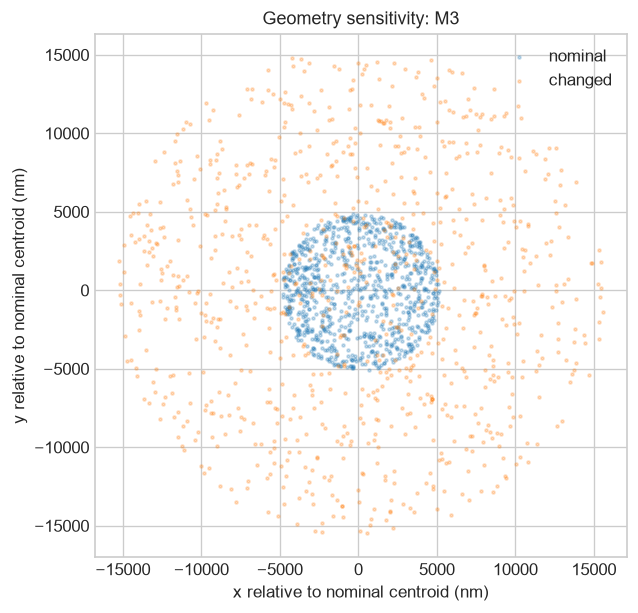

Changed radius: -757.480517710 mm
Changed conic:  0.026174
Centroid shift: 244.591 nm


In [10]:
def compare_geometry_change(mirror_name, radius_scale=1.0, conic_delta=0.0,
                            asphere_scale=1.0, num_rays=1200):
    trial = deepcopy(MIRRORS)
    changed = next((m for m in trial if m["name"] == mirror_name), None)
    if changed is None:
        raise ValueError(f"Unknown mirror {mirror_name!r}; choose M1...M5")
    changed["radius_mm"] *= float(radius_scale)
    changed["conic"] += float(conic_delta)
    changed["asphere_coeffs"] = [float(asphere_scale) * c for c in changed["asphere_coeffs"]]

    nominal_system = build_optiland_system(MIRRORS)
    trial_system = build_optiland_system(trial)
    xn, yn, wn = trace_field_spot(nominal_system, Hy=0.0, num_rays=num_rays)
    xt, yt, wt = trace_field_spot(trial_system, Hy=0.0, num_rays=num_rays)
    xref, yref = np.average(xn, weights=wn), np.average(yn, weights=wn)

    fig, ax = plt.subplots(figsize=(6.2, 5.0), constrained_layout=True)
    ax.scatter((xn - xref) * 1e6, (yn - yref) * 1e6, s=3, alpha=0.25, label="nominal")
    ax.scatter((xt - xref) * 1e6, (yt - yref) * 1e6, s=3, alpha=0.25, label="changed")
    ax.set(title=f"Geometry sensitivity: {mirror_name}",
           xlabel="x relative to nominal centroid (nm)",
           ylabel="y relative to nominal centroid (nm)")
    ax.set_aspect("equal", adjustable="box")
    ax.legend()
    sensitivity_data = pd.concat([
        pd.DataFrame({"case": "nominal", "x_relative_nm": (xn - xref) * 1e6,
                      "y_relative_nm": (yn - yref) * 1e6, "relative_ray_power": wn}),
        pd.DataFrame({"case": "changed", "x_relative_nm": (xt - xref) * 1e6,
                      "y_relative_nm": (yt - yref) * 1e6, "relative_ray_power": wt}),
    ], ignore_index=True)
    safe_name = mirror_name.lower().replace(" ", "_")
    sensitivity_data.to_csv(DATA_DIR / f"geometry_sensitivity_{safe_name}.csv", index=False)
    export_figure(fig, f"05_geometry_sensitivity_{safe_name}")
    plt.show()
    shift_nm = np.hypot(np.average(xt, weights=wt) - xref, np.average(yt, weights=wt) - yref) * 1e6
    print(f"Changed radius: {changed['radius_mm']:.9f} mm")
    print(f"Changed conic:  {changed['conic']:.9g}")
    print(f"Centroid shift: {shift_nm:.3f} nm")
    return trial_system

# Demonstration: +0.02% radius change on M3. Edit or comment this call as desired.
trial_system = compare_geometry_change("M3", radius_scale=1.0002, num_rays=900)


## 6. Interactive coating fine-tuning

The widget changes a temporary copy of one coating, so it does not silently overwrite `MIRRORS`. Copy preferred slider values into the main configuration cell when you want them to affect every downstream result.


In [ ]:
try:
    from ipywidgets import interact, Dropdown, FloatSlider, IntSlider

    @interact(
        mirror_name=Dropdown(options=[m["name"] for m in MIRRORS], value="M1", description="Mirror"),
        d_mo_nm=FloatSlider(min=2.4, max=3.2, step=0.01, value=BASE_COATING["d_mo_nm"], description="Mo (nm)"),
        d_si_nm=FloatSlider(min=3.7, max=4.6, step=0.01, value=BASE_COATING["d_si_nm"], description="Si (nm)"),
        d_ru_nm=FloatSlider(min=0.0, max=4.0, step=0.05, value=BASE_COATING["d_ru_nm"], description="Ru (nm)"),
        n_pairs=IntSlider(min=10, max=70, step=1, value=BASE_COATING["n_pairs"], description="Pairs"),
        roughness_nm=FloatSlider(min=0.0, max=0.8, step=0.02, value=BASE_COATING["roughness_nm"], description="Rough (nm)"),
    )
    def coating_tuner(mirror_name, d_mo_nm, d_si_nm, d_ru_nm, n_pairs, roughness_nm):
        mirror = next(m for m in MIRRORS if m["name"] == mirror_name)
        cfg = deepcopy(mirror["coating"])
        cfg.update(d_mo_nm=d_mo_nm, d_si_nm=d_si_nm, d_ru_nm=d_ru_nm,
                   n_pairs=n_pairs, roughness_nm=roughness_nm)
        wl = np.linspace(12.5, 14.5, 301)
        angles = np.linspace(max(0.0, mirror["nominal_aoi_deg"] - 6.0),
                             mirror["nominal_aoi_deg"] + 6.0, 241)
        R_wl = multilayer_reflectivity(cfg, wl, mirror["nominal_aoi_deg"])
        R_a = multilayer_reflectivity(cfg, WAVELENGTH_NM, angles)
        fig, axes = plt.subplots(1, 2, figsize=(11, 3.7), constrained_layout=True)
        axes[0].plot(wl, 100 * R_wl)
        axes[0].axvline(WAVELENGTH_NM, color="k", ls="--", lw=1)
        axes[0].set(xlabel="wavelength (nm)", ylabel="R (%)", title=f"{mirror_name}: spectrum")
        axes[1].plot(angles, 100 * R_a)
        axes[1].axvline(mirror["nominal_aoi_deg"], color="k", ls="--", lw=1)
        axes[1].set(xlabel="AOI from normal (deg)", ylabel="R (%)",
                    title=f"{mirror_name}: angular response at {WAVELENGTH_NM:.1f} nm")
        plt.show()
        r0 = multilayer_reflectivity(cfg, WAVELENGTH_NM, mirror["nominal_aoi_deg"])
        print(f"R({WAVELENGTH_NM:.1f} nm, {mirror['nominal_aoi_deg']:.2f}°) = {100*r0:.3f}%")

except ImportError:
    warnings.warn("ipywidgets is unavailable; edit MIRRORS directly and rerun.")


interactive(children=(Dropdown(description='Mirror', options=('M1', 'M2', 'M3', 'M4', 'M5'), value='M1'), Floa…

## Interpretation and limitations

- **Coating edits** change throughput, spectral bandwidth, polarization response, and pupil apodization. In this notebook they do not change ray directions.
- **Radius, conic, asphere, spacing, decenter, and tilt edits** change the ray path and wafer-plane footprint. Rebuild `system` after editing them.
- `aoi_half_span_deg` is an editable approximation for plotting intensity across a mirror footprint. A production workflow should obtain local AOI from the fully optimized, unobscured off-axis prescription and apply a spatially graded multilayer.
- The public prescription is an older 13.1 nm/NA 0.18 five-mirror design evaluated here at 13.5 nm. A modern commercial EUV projection objective is different and generally proprietary.
- Geometrical spots do not predict lithographic imaging by themselves. A quantitative scanner model also needs coherent/partially coherent mask propagation, multilayer phase, polarization, flare/scatter, figure error, vibration, thermal drift, resist response, and diffraction/MTF analysis.

### Sources

- [Optiland 0.5.8 documentation](https://optiland.readthedocs.io/en/latest/) and its [reflective compact-telescope example](https://optiland.readthedocs.io/en/latest/gallery/reflective/compact_telescope.html)
- [Optiland even-asphere definition](https://optiland.readthedocs.io/en/latest/api/geometries/geometries.even_asphere.html)
- [US6072852A: five-mirror EUV projection system](https://patents.google.com/patent/US6072852A/en), especially Tables 3, 5, 6, and 7
- [US8144830B2 optical constants at 13.5 nm](https://patents.justia.com/patent/8144830)

For reproducible studies, record the Optiland version, optical-constant dataset, coating-stack convention, and every modified parameter alongside exported results.
